# GEOS-CF vs. EPA AQS: Beltsville, MD Surface Ozone — 2025

This notebook demonstrates a real-world comparison between:
- **EPA AQS** ground-based hourly ozone observations (Beltsville, MD BBOX)
- **NASA GEOS-CF** assimilation surface ozone at the same location

Data period: **January 1 – December 31, 2025**

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import xarray as xr

from atmoz.surface.AirNow import AirNow
from atmoz.models.dev_GEOS_CF import GEOS_CF

## 1. EPA AQS Hourly Ozone Data

Download the EPA AQS pre-generated hourly ozone file for 2025 (all US sites),
then apply a bounding box filter to isolate Beltsville, MD monitoring stations.

In [2]:
# Download EPA AQS pre-generated hourly ozone file for 2025
# Parameter code 44201 = Ozone; file: hourly_44201_2025.zip
aqs_data = AirNow.download(endpoint="aqs", parameters=["ozone"], resolutions=["hourly"], years=[2025])
df_aqs = aqs_data["hourly_44201_2025.csv"]

print(f"Total rows in national file: {len(df_aqs):,}")
print(f"Columns: {list(df_aqs.columns)}")

Total rows in national file: 5,827,634
Columns: ['State Code', 'County Code', 'Site Num', 'Parameter Code', 'POC', 'Latitude', 'Longitude', 'Datum', 'Parameter Name', 'Date Local', 'Time Local', 'Date GMT', 'Time GMT', 'Sample Measurement', 'Units of Measure', 'MDL', 'Uncertainty', 'Qualifier', 'Method Type', 'Method Code', 'Method Name', 'State Name', 'County Name', 'Date of Last Change']


In [3]:
# Beltsville, MD bounding box
BBOX = dict(min_lat=39.00, max_lat=39.10, min_lon=-76.95, max_lon=-76.80)

df_aqs["Latitude"]  = pd.to_numeric(df_aqs["Latitude"],  errors="coerce")
df_aqs["Longitude"] = pd.to_numeric(df_aqs["Longitude"], errors="coerce")

mask = (
    df_aqs["Latitude"].between(BBOX["min_lat"], BBOX["max_lat"]) &
    df_aqs["Longitude"].between(BBOX["min_lon"], BBOX["max_lon"])
)
df_beltsville = df_aqs[mask].copy()

sites = df_beltsville[["State Code", "County Code", "Site Num", "Latitude", "Longitude", "County Name"]].drop_duplicates()
print(f"Sites found in BBOX: {len(sites)}")
display(sites)

Sites found in BBOX: 2


,State Code,County Code,Site Num,Latitude,Longitude,County Name
2744251,24,033,0030,39.055277,-76.878333,Prince George's
2757132,24,033,9991,39.028400,-76.817100,Prince George's


In [4]:
# Build UTC datetime index and convert units: ppm -> ppb
print("Units in AQS file:", df_beltsville["Units of Measure"].unique())

df_beltsville["UTC"] = pd.to_datetime(
    df_beltsville["Date GMT"] + " " + df_beltsville["Time GMT"],
    format="%Y-%m-%d %H:%M",
    utc=True,
)
df_beltsville.set_index("UTC", inplace=True)
df_beltsville.sort_index(inplace=True)

# AQS ozone is reported in ppm -> multiply x1000 for ppb
df_beltsville["O3_ppb"] = df_beltsville["Sample Measurement"] * 1000.0

# Select primary site (most non-NaN observations)
site_counts = df_beltsville.groupby(["State Code", "County Code", "Site Num"])["O3_ppb"].count()
primary_site = site_counts.idxmax()
state_code, county_code, site_num = primary_site

df_site = df_beltsville[
    (df_beltsville["State Code"]  == state_code)  &
    (df_beltsville["County Code"] == county_code) &
    (df_beltsville["Site Num"]    == site_num)
].copy()

site_lat = float(df_site["Latitude"].iloc[0])
site_lon = float(df_site["Longitude"].iloc[0])

epa_o3 = df_site["O3_ppb"].rename("EPA AQS O3 (ppb)")

print(f"Primary site: {state_code}-{county_code}-{site_num}  ({site_lat:.4f}, {site_lon:.4f})")
print(f"Valid hourly observations: {epa_o3.dropna().shape[0]:,}")
print(f"O3 range: {epa_o3.min():.1f} – {epa_o3.max():.1f} ppb")

Units in AQS file: <ArrowStringArray>
['Parts per million']
Length: 1, dtype: str
Primary site: 24-033-0030  (39.0553, -76.8783)
Valid hourly observations: 7,084
O3 range: 0.0 – 81.0 ppb


## 2. GEOS-CF Assimilation Surface Ozone

Fetch NASA GEOS-CF AQC (surface air quality) O3 at the EPA site coordinates
for the full year 2025 via OPeNDAP. Variables are returned in mol/mol — the
unit-detection cell below converts to ppb.

In [5]:
geos = GEOS_CF()

geos.fetch(
    lat=site_lat,
    lon=site_lon,
    start_date="2025-01-01",
    end_date="2025-12-31",
    collection="aqc",
    mode="assim",
    variables=["o3"],
    cache_dir=".geos_cf_cache",   # cache to disk; re-runs load instantly
)

geos_key = next(iter(geos.data))
print("Dataset key:", geos_key)
print(geos.data[geos_key])

Loading from cache: .geos_cf_cache/geos_cf_96c6a9000596.nc
Dataset key: ('39.055277x-76.878333', 'assim', 'aqc')
<xarray.Dataset> Size: 105kB
Dimensions:  (time: 8760, lev: 1)
Coordinates:
  * time     (time) datetime64[ns] 70kB 2025-01-01T00:30:00.000003 ... 2025-1...
  * lev      (lev) float64 8B 72.0
    lat      float64 8B 39.0
    lon      float64 8B -77.0
Data variables:
    o3       (time, lev) float32 35kB 1.994e-08 1.796e-08 ... 4.562e-09
Attributes: (12/14)
    title:                GEOS CF (Composition Forecast)
    Conventions:          COARDS\nGrADS
    dataType:             Grid
    history:              Wed May 13 17:53:11 GMT 2026 : imported by GrADS Da...
    extra_das_attribute:  This is an example of metadata added using a supple...
    lat_requested:        39.054
    ...                   ...
    lon_actual:           -77.0
    collection:           aqc
    mode:                 assim
    start_date:           2025-01-01
    end_date:             2025-12-31
    uni

In [6]:
# squeeze the single-element lev dimension (surface level) before converting
geos_o3_raw = geos.data[geos_key]["o3"].squeeze("lev").to_series().rename("GEOS-CF O3")

print(f"GEOS-CF O3 time steps: {len(geos_o3_raw):,}")
print(f"GEOS-CF O3 raw range: {geos_o3_raw.min():.4e} – {geos_o3_raw.max():.4e}")
print()

# Units: OPeNDAP AQC gas species are mol/mol
# ~2e-8 to 1e-7 → 20 to 100 ppb after ×1e9
sample_val = geos_o3_raw.median()
if sample_val < 0.01:
    print("Detected mol/mol units → converting to ppb (×1e9)")
    geos_o3 = (geos_o3_raw * 1e9).rename("GEOS-CF O3 (ppb)")
elif sample_val < 5.0:
    print("Detected ppm units → converting to ppb (×1e3)")
    geos_o3 = (geos_o3_raw * 1e3).rename("GEOS-CF O3 (ppb)")
else:
    print("Detected ppb units → no conversion needed")
    geos_o3 = geos_o3_raw.rename("GEOS-CF O3 (ppb)")

# GEOS-CF tavg_1hr timestamps are at :30 (center of avg window); floor to :00
# so they align with EPA AQS which is timestamped at the start of the hour
geos_o3.index = geos_o3.index.floor("h")

# Localize to UTC for merge with EPA data
if geos_o3.index.tz is None:
    geos_o3.index = geos_o3.index.tz_localize("UTC")

print(f"GEOS-CF O3 range (ppb): {geos_o3.min():.1f} – {geos_o3.max():.1f}")

GEOS-CF O3 time steps: 8,760
GEOS-CF O3 raw range: 3.8398e-14 – 1.2247e-07

Detected mol/mol units → converting to ppb (×1e9)
GEOS-CF O3 range (ppb): 0.0 – 122.5


## 3. Comparison

Align the two hourly time series and compute statistics.

In [7]:
# Align to common UTC hourly index
# GEOS-CF index is already UTC; ensure EPA index is too
if epa_o3.index.tz is None:
    epa_o3.index = epa_o3.index.tz_localize("UTC")
if geos_o3.index.tz is None:
    geos_o3.index = geos_o3.index.tz_localize("UTC")

combined = pd.concat([epa_o3, geos_o3], axis=1).dropna()
combined.columns = ["EPA", "GEOS-CF"]

# Daily means for smoother time series
epa_daily   = epa_o3.resample("1D").mean()
geos_daily  = geos_o3.resample("1D").mean()

# 7-day rolling mean for cleaner visual
epa_7d  = epa_daily.rolling(7, center=True, min_periods=4).mean()
geos_7d = geos_daily.rolling(7, center=True, min_periods=4).mean()

diff_daily = (geos_daily - epa_daily).dropna()

print(f"Paired hourly samples: {len(combined):,}")

Paired hourly samples: 7,084


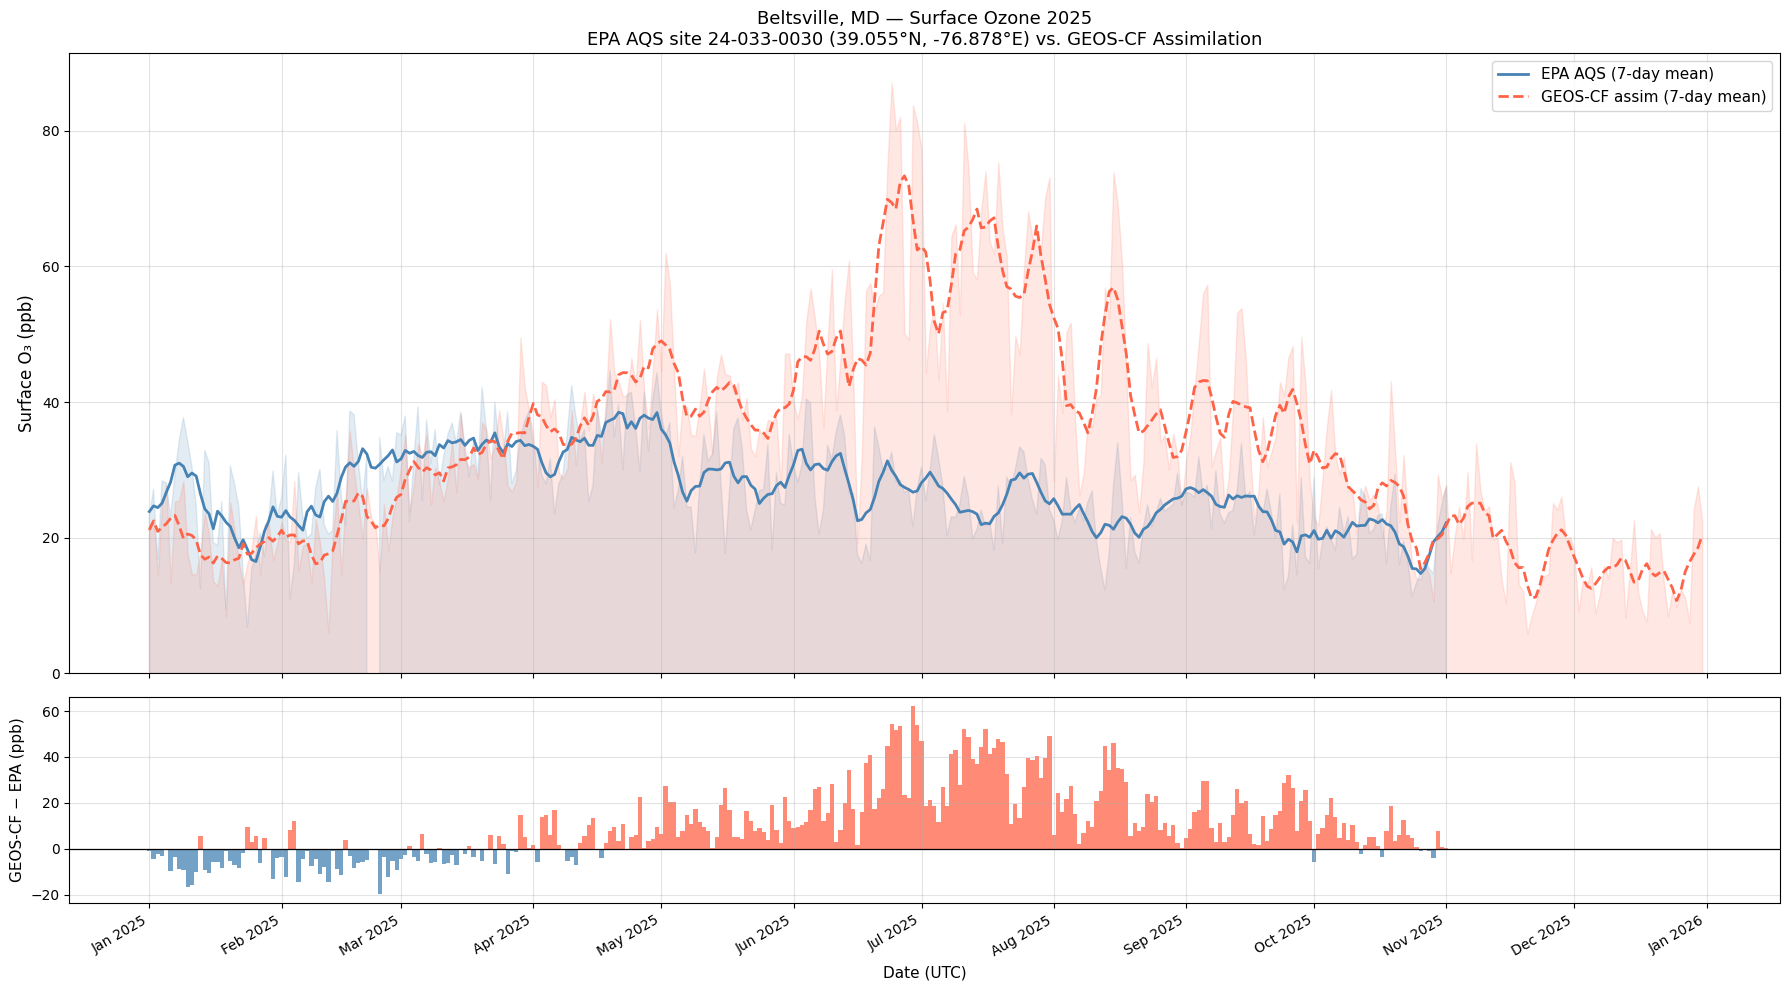

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1]})

# ── Top panel: time series ──────────────────────────────────────────────────
ax = axes[0]
ax.fill_between(epa_daily.index, epa_daily.values, alpha=0.15, color="steelblue")
ax.fill_between(geos_daily.index, geos_daily.values, alpha=0.15, color="tomato")
ax.plot(epa_7d.index,  epa_7d.values,  color="steelblue", lw=2.0, label="EPA AQS (7-day mean)")
ax.plot(geos_7d.index, geos_7d.values, color="tomato",    lw=2.0, linestyle="--",
        label="GEOS-CF assim (7-day mean)")

ax.set_ylabel("Surface O₃ (ppb)", fontsize=12)
ax.set_title(
    f"Beltsville, MD — Surface Ozone 2025\n"
    f"EPA AQS site {state_code}-{county_code}-{site_num} "
    f"({site_lat:.3f}°N, {site_lon:.3f}°E) vs. GEOS-CF Assimilation",
    fontsize=13,
)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.35)
ax.set_ylim(bottom=0)

# ── Bottom panel: daily bias ────────────────────────────────────────────────
ax2 = axes[1]
colors = np.where(diff_daily.values >= 0, "tomato", "steelblue")
ax2.bar(diff_daily.index, diff_daily.values, color=colors, alpha=0.75, width=1.0)
ax2.axhline(0, color="black", lw=0.9)
ax2.set_ylabel("GEOS-CF − EPA (ppb)", fontsize=11)
ax2.set_xlabel("Date (UTC)", fontsize=11)
ax2.grid(True, alpha=0.35)

ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax2.xaxis.set_major_locator(mdates.MonthLocator())
fig.autofmt_xdate(rotation=30)

plt.tight_layout()
plt.show()

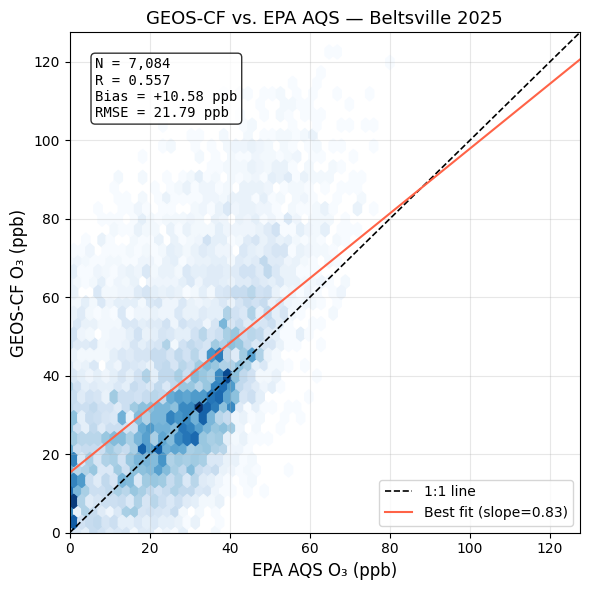

N       = 7,084
R       = 0.557
Bias    = +10.58 ppb  (GEOS-CF − EPA)
RMSE    = 21.79 ppb


In [9]:
# ── Scatter plot + statistics ───────────────────────────────────────────────
r    = combined.corr().iloc[0, 1]
bias = (combined["GEOS-CF"] - combined["EPA"]).mean()
rmse = np.sqrt(((combined["GEOS-CF"] - combined["EPA"]) ** 2).mean())
n    = len(combined)

fig, ax = plt.subplots(figsize=(6, 6))

lims = [max(0, combined.min().min() - 5), combined.max().max() + 5]
ax.hexbin(combined["EPA"], combined["GEOS-CF"], gridsize=40,
          cmap="Blues", mincnt=1)
ax.plot(lims, lims, "k--", lw=1.2, label="1:1 line")

# Linear fit
m, b = np.polyfit(combined["EPA"], combined["GEOS-CF"], 1)
x_fit = np.array(lims)
ax.plot(x_fit, m * x_fit + b, color="tomato", lw=1.5,
        label=f"Best fit (slope={m:.2f})")

ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("EPA AQS O₃ (ppb)", fontsize=12)
ax.set_ylabel("GEOS-CF O₃ (ppb)", fontsize=12)
ax.set_title(
    f"GEOS-CF vs. EPA AQS — Beltsville 2025",
    fontsize=13,
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

stats_txt = f"N = {n:,}\nR = {r:.3f}\nBias = {bias:+.2f} ppb\nRMSE = {rmse:.2f} ppb"
ax.text(0.05, 0.95, stats_txt, transform=ax.transAxes, va="top",
        fontsize=10, family="monospace",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.show()

print(f"N       = {n:,}")
print(f"R       = {r:.3f}")
print(f"Bias    = {bias:+.2f} ppb  (GEOS-CF − EPA)")
print(f"RMSE    = {rmse:.2f} ppb")